# **Домашнее задание 1: Оптический поток и динамика видео**

### **Цель**

Освоить практическое применение оптического потока для анализа движения, научиться строить полные видеопайплайны, включающие вычисление потока, фильтрацию, warping и стабилизацию. Студент выбирает **одну** из двух инженерных задач: построение мини-системы **стабилизации камеры** или создание **трекинг-модуля движения**, анализирующего траектории и устойчивость методов Lucas–Kanade и Farnebäck.

---

# **Вариант A: Мини-система стабилизации камеры**

### **Задание**

1. Выбрать видеоролик с заметной дрожью камеры (телефонная съёмка, action-камера, GoPro, записанная вручную панорама).
2. Вычислить плотный оптический поток (Farnebäck) или разреженный (LK) и оценить глобальное движение камеры по кадрам (аффинная модель или гомография).
3. Сгладить траекторию движения низкочастотным фильтром (скользящее окно, экспоненциальное сглаживание или фильтр Калмана по желанию).
4. Выполнить **компенсацию движения** через warp каждого кадра к стабилизированной траектории.
5. Сформировать стабилизированное видео.
6. Построить визуальные сравнения «до/после» и провести **error analysis**: какие участки стабилизируются плохо и почему (оптический поток, тени, motion blur, нехватка текстуры, ошибки глобальной модели).

---

In [2]:
conda info --envs

# conda environments:
#
base                  *  /Users/artemhorosilov/opt/anaconda3
cv_env                   /Users/artemhorosilov/opt/anaconda3/envs/cv_env


Note: you may need to restart the kernel to use updated packages.


## 1. Выбрать видеоролик с заметной дрожью камеры (телефонная съёмка, action-камера, GoPro, записанная вручную панорама).

In [6]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import Video

In [40]:
cap = cv2.VideoCapture('video.mp4')

In [41]:
Video('video.mp4')

## 2. Вычислить плотный оптический поток (Farnebäck) или разреженный (LK) и оценить глобальное движение камеры по кадрам (аффинная модель или гомография).

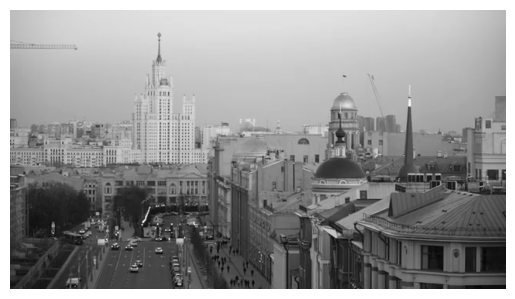

In [42]:
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

#### Плотный оптический поток (Farnebäck)

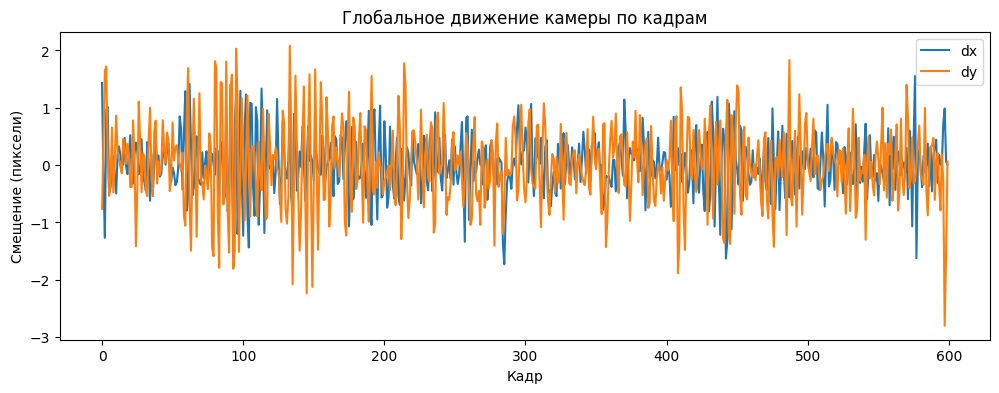

In [43]:
dx_list, dy_list = [], []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray,
        None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )
    
    dx = np.mean(flow[...,0])
    dy = np.mean(flow[...,1])
    
    dx_list.append(dx)
    dy_list.append(dy)
    
    prev_gray = gray

cap.release()
plt.figure(figsize=(12,4))
plt.plot(dx_list, label='dx')
plt.plot(dy_list, label='dy')
plt.xlabel('Кадр')
plt.ylabel('Смещение (пиксели)')
plt.title('Глобальное движение камеры по кадрам')
plt.legend()
plt.show()

####  Разреженный (LK) и аффинная модель

In [44]:
cap = cv2.VideoCapture("video.mp4")
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

feature_params = dict(maxCorners=200, qualityLevel=0.01, minDistance=30)
lk_params = dict(winSize=(15,15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

affine_matrices = []

while True:
    ret, frame = cap.read()
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, mask=None, **feature_params)
    if prev_pts is None:
        prev_gray = gray
        continue
    
    next_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_pts, None, **lk_params)
    
    good_prev = prev_pts[status==1]
    good_next = next_pts[status==1]
    

    M, inliers = cv2.estimateAffinePartial2D(good_prev, good_next)
    
    affine_matrices.append(M)
    prev_gray = gray

In [50]:
affine_matrices[0]

array([[ 1.00023959e+00, -1.02071168e-04,  2.15533746e+00],
       [ 1.02071168e-04,  1.00023959e+00, -1.26685195e+00]])

## 3. Сгладить траекторию движения низкочастотным фильтром (скользящее окно, экспоненциальное сглаживание или фильтр Калмана по желанию).

#### Farnebäck

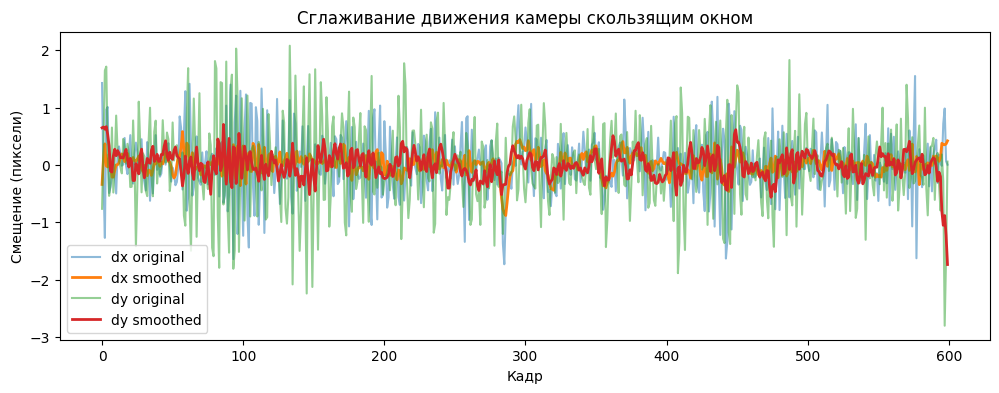

In [53]:
dx_array = np.array(dx_list)
dy_array = np.array(dy_list)

window_size = 5
kernel = np.ones(window_size) / window_size

dx_smooth = cv2.filter2D(dx_array, -1, kernel)
dy_smooth = cv2.filter2D(dy_array, -1, kernel)

plt.figure(figsize=(12,4))
plt.plot(dx_array, label='dx original', alpha=0.5)
plt.plot(dx_smooth, label='dx smoothed', linewidth=2)
plt.plot(dy_array, label='dy original', alpha=0.5)
plt.plot(dy_smooth, label='dy smoothed', linewidth=2)
plt.xlabel('Кадр')
plt.ylabel('Смещение (пиксели)')
plt.title('Сглаживание движения камеры скользящим окном')
plt.legend()
plt.show()

#### LK

In [54]:
half_win = window_size // 2

tx = np.array([M[0,2] for M in affine_matrices])
ty = np.array([M[1,2] for M in affine_matrices])

tx_padded = np.pad(tx, (half_win, half_win), mode='edge')
ty_padded = np.pad(ty, (half_win, half_win), mode='edge')

tx_smooth = np.convolve(tx_padded, np.ones(window_size)/window_size, mode='valid')
ty_smooth = np.convolve(ty_padded, np.ones(window_size)/window_size, mode='valid')

affine_smooth = []
for i, M in enumerate(affine_matrices):
    M_s = M.copy()
    M_s[0,2] = tx_smooth[i]
    M_s[1,2] = ty_smooth[i]
    affine_smooth.append(M_s)

## 4. Выполнить **компенсацию движения** через warp каждого кадра к стабилизированной траектории. 5. Сформировать стабилизированное видео.

#### Farnebäck

In [62]:
cap = cv2.VideoCapture("video.mp4")
ret, frame = cap.read()

h, w = frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*'avc1')
out = cv2.VideoWriter('video_stabilized_farneback.mp4', fourcc, 30, (w, h))

for i in range(len(dx_smooth)):
    ret, frame = cap.read()

    map_x, map_y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = map_x.astype(np.float32) - dx_smooth[i] 
    map_y = map_y.astype(np.float32) - dy_smooth[i]

    stabilized_frame = cv2.remap(frame, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    out.write(stabilized_frame)

cap.release()
out.release()

OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
2026-02-23 18:40:41.266 python[87246:102134338] WARNING: -finishWriting shou

#### LK

In [63]:
cap = cv2.VideoCapture("video.mp4")
ret, frame = cap.read()
h, w = frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*'avc1')
out = cv2.VideoWriter('video_stabilized_lk.mp4', fourcc, 30, (w,h))

for i, M in enumerate(affine_matrices):
    ret, frame = cap.read()
    
    M_smooth = affine_smooth[i]
    dx = M_smooth[0,2] - M[0,2]
    dy = M_smooth[1,2] - M[1,2]
    warp_M = np.array([[1,0,dx],
                       [0,1,dy]], dtype=np.float32
    stabilized_frame = cv2.warpAffine(frame, warp_M, (w,h))

    out.write(stabilized_frame)

cap.release()
out.release()

OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
OpenCV: AVF: waiting to write video data.
2026-02-23 18:43:17.739 python[87246:102134338] WARNING: -finishWriting should not be called on the main thread.


## 6. Построить визуальные сравнения «до/после» и провести **error analysis**: какие участки стабилизируются плохо и почему (оптический поток, тени, motion blur, нехватка текстуры, ошибки глобальной модели).


- Original

In [67]:
Video('video.mp4')

- Farnebäck

In [68]:
Video('video_stabilized_farneback.mp4')

- Lucas-Kanade

In [69]:
Video('video_stabilized_lk.mp4')

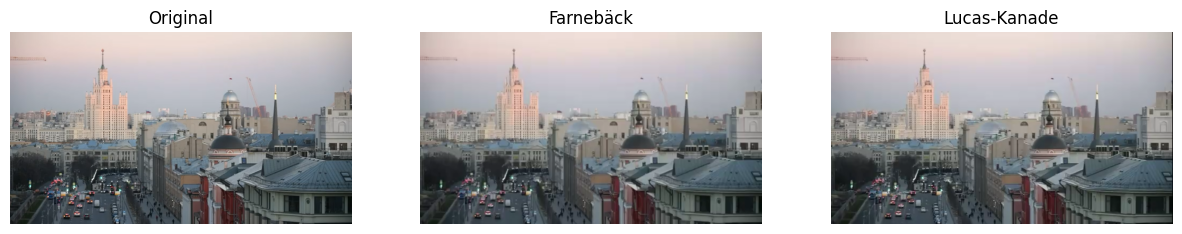

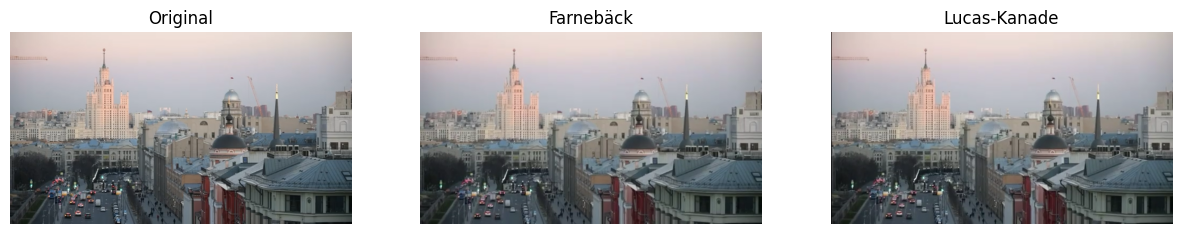

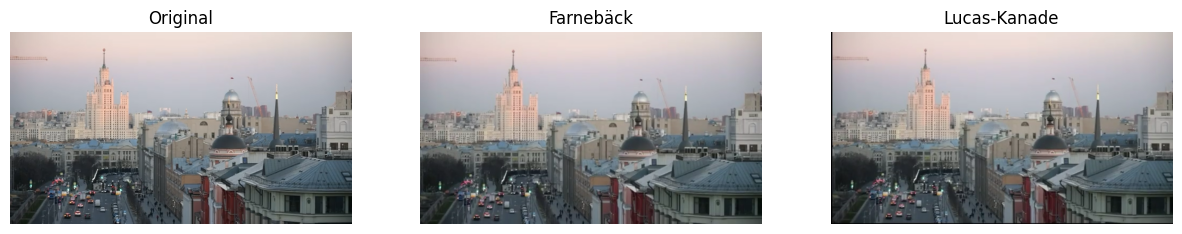

In [78]:
import cv2
import matplotlib.pyplot as plt

cap_orig = cv2.VideoCapture("video.mp4")
cap_fb   = cv2.VideoCapture("video_stabilized_farneback.mp4")
cap_lk   = cv2.VideoCapture("video_stabilized_lk.mp4")

frame_id = 0
while True:
    ret1, frame_orig = cap_orig.read()
    ret2, frame_fb   = cap_fb.read()
    ret3, frame_lk   = cap_lk.read()

    frame_orig = cv2.cvtColor(frame_orig, cv2.COLOR_BGR2RGB)
    frame_fb   = cv2.cvtColor(frame_fb, cv2.COLOR_BGR2RGB)
    frame_lk   = cv2.cvtColor(frame_lk, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(frame_orig)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(frame_fb)
    plt.title("Farnebäck")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(frame_lk)
    plt.title("Lucas-Kanade")
    plt.axis('off')

    plt.show()

    frame_id += 1
    if frame_id >= 3:
        break

cap_orig.release()
cap_fb.release()
cap_lk.release()

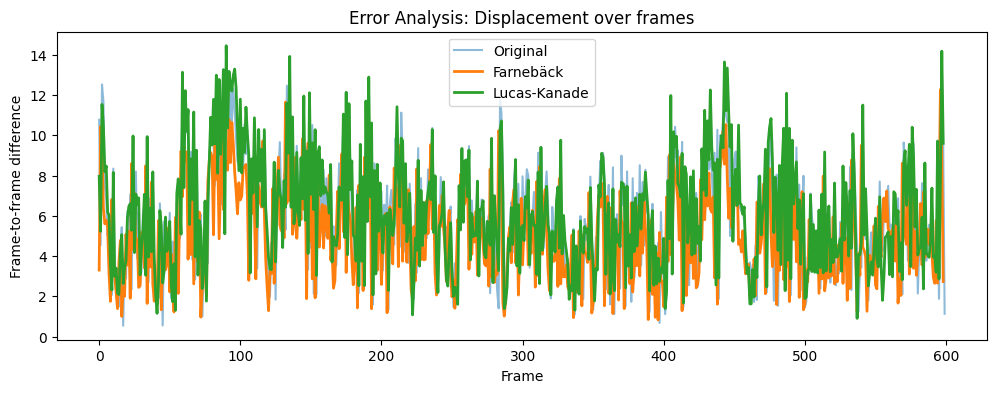

In [80]:
import numpy as np

def frame_displacement(video_path):
    cap = cv2.VideoCapture(video_path)
    ret, prev = cap.read()
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    displacements = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = gray.astype(np.float32) - prev_gray.astype(np.float32)
        disp = np.mean(np.abs(diff))
        displacements.append(disp)
        prev_gray = gray

    cap.release()
    return displacements

disp_orig = frame_displacement("video.mp4")
disp_fb = frame_displacement("video_stabilized_farneback.mp4")
disp_lk = frame_displacement("video_stabilized_lk.mp4")

plt.figure(figsize=(12,4))
plt.plot(disp_orig, label='Original', alpha=0.5)
plt.plot(disp_fb, label='Farnebäck', linewidth=2)
plt.plot(disp_lk, label='Lucas-Kanade', linewidth=2)
plt.xlabel('Frame')
plt.ylabel('Frame-to-frame difference')
plt.title('Error Analysis: Displacement over frames')
plt.legend()
plt.show()

In [81]:
print("Original:", np.mean(disp_orig))
print("Farneback stabilized:", np.mean(disp_fb))
print("Lucas-Kanade stabilized:", np.mean(disp_lk))

Original: 6.0441537
Farneback stabilized: 5.131956
Lucas-Kanade stabilized: 6.2069244


Из метрик  видно, что метод Farneback улучшил стабилизацию, так как межкадровые изменения уменьшились.
Метод Lucas–Kanade показал результат хуже, чем оригинальное видео, что означает, что стабилизация в данном случае работает менее эффективно и добавляет ошибки в движение. Особенно это заметно при паддинге, скорее из-за этого метрика ухудшилась, потому что это сильный переход на черное

Камера в оригинаале слишком быстро движется, изображение становится размытым. В таких кадрах алгоритмы оптического потока хуже определяют движение пикселей, поэтому оценка движения камеры становится менее точной.

На однородных поверхностях (стены, небо, дорога) мало характерных точек. В таких местах Lucas–Kanade трудно найти стабильные feature points, поэтому движение оценивается хуже. Также в кадре есть движущиеся машины, алгоритм может принять их движение за движение камеры.

#### Выводы:

В домашке Farneback показал более устойчивую стабилизацию, так как использует плотный оптический поток, который учитывает движение всех пикселей. (но визуально ничего не поменялось) 

Метод Lucas–Kanade, основанный на разреженных feature points, оказался более чувствительным к нехватке текстуры и ошибкам трекинга, поэтому его результат оказался менее стабильным.

# **Требования к сдаче**

Репозиторий на GitHub:

* `src/` или ноутбук с кодом вычисления оптического потока и всего пайплайна.
* `README.md` c описанием выбранного варианта (A или B), параметров, применённых фильтров и основных наблюдений.
* Визуализации:
  – для варианта A: примерные кадры «до/после», графики траектории движения камеры, примеры warping-а;
  – для варианта B: траектории LK, карты плотного потока, маски движения.
* При варианте A — итоговое стабилизированное видео.
* При варианте B — сравнительный отчёт о различиях LK и Farnebäck.

---

# **Критерии оценки**

| Баллы | Критерий                                                                      |
| ----- | ----------------------------------------------------------------------------- |
| 0–3   | Полнота: реализованы все этапы выбранного варианта (A или B).                 |
| 0–3   | Код: чистый, воспроизводимый, корректно использует OpenCV.                    |
| 0–2   | Анализ: качественный разбор ошибок, интерпретация результатов, выводы.        |
| 0–2   | Репозиторий: аккуратность, читаемость, примеры визуализаций, понятный README. |

**Максимум: 10 баллов.**
